#### **Dataset Description**

This dataset includes real estate property listings with details on attributes, location, and pricing.

##### **Attributes**

1. **property_id**: Unique identifier for each property (`int64`).
2. **location_id**: Identifier for the property's location (`int64`).
3. **page_url**: URL link to property details (`object`).
4. **property_type**: Type of property (e.g., house, apartment) (`object`).
5. **price**: Price of the property (`int64`).
6. **location**: Specific location (e.g., neighborhood) (`object`).
7. **city**: City of the property (`object`).
8. **province_name**: Province where the property is located (`object`).
9. **latitude**: Geographic latitude (`float64`).
10. **longitude**: Geographic longitude (`float64`).
11. **baths**: Number of bathrooms (`int64`).
12. **area**: Total area size (e.g., Marla, Kanal) (`object`).
13. **purpose**: Listing purpose (e.g., sale, rent) (`object`).
14. **bedrooms**: Number of bedrooms (`int64`).
15. **date_added**: Date when the listing was added (`object`).
16. **agency**: Real estate agency (`object`, contains missing values).
17. **agent**: Responsible agent (`object`, contains missing values).
18. **Area Type**: Measurement type (e.g., Marla, Kanal) (`object`).
19. **Area Size**: Size of the area (`float64`).
20. **Area Category**: Area size category (e.g., 0-5 Marla) (`object`).

**Total Rows**: 168,446  
**Total Columns**: 20


#### **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import folium
import datetime 
from scipy import stats
from scipy.stats import zscore
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import LabelEncoder
from folium.plugins import MarkerCluster
from IPython.display import display, HTML
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

#### **Load the Dataset and Initial Inception**

In [2]:
# Set the display option
pd.options.display.max_columns = None

df = pd.read_csv('zameen-updated.csv')

# check the 5 rows of dataset
df.head()

,property_id,location_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent,Area Type,Area Size,Area Category
0,237062,3325,https://www.zameen.com/Property/g_10_g_10_2_gr...,Flat,10000000,G-10,Islamabad,Islamabad Capital,33.679890,73.012640,2,4 Marla,For Sale,2,02-04-2019,NaN,NaN,Marla,4.0,0-5 Marla
1,346905,3236,https://www.zameen.com/Property/e_11_2_service...,Flat,6900000,E-11,Islamabad,Islamabad Capital,33.700993,72.971492,3,5.6 Marla,For Sale,3,05-04-2019,NaN,NaN,Marla,5.6,5-10 Marla
2,386513,764,https://www.zameen.com/Property/islamabad_g_15...,House,16500000,G-15,Islamabad,Islamabad Capital,33.631486,72.926559,6,8 Marla,For Sale,5,07-17-2019,NaN,NaN,Marla,8.0,5-10 Marla
3,656161,340,https://www.zameen.com/Property/islamabad_bani...,House,43500000,Bani Gala,Islamabad,Islamabad Capital,33.707573,73.151199,4,2 Kanal,For Sale,4,04-05-2019,NaN,NaN,Kanal,2.0,1-5 Kanal
4,841645,3226,https://www.zameen.com/Property/dha_valley_dha...,House,7000000,DHA Defence,Islamabad,Islamabad Capital,33.492591,73.301339,3,8 Marla,For Sale,3,07-10-2019,Easy Property,Muhammad Junaid Ceo Muhammad Shahid Director,Marla,8.0,5-10 Marla


In [3]:
# Get the number of rows and columns
df.shape
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 168446
Number of columns: 20


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 168446 entries, 0 to 168445
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   property_id    168446 non-null  int64  
 1   location_id    168446 non-null  int64  
 2   page_url       168446 non-null  str    
 3   property_type  168446 non-null  str    
 4   price          168446 non-null  int64  
 5   location       168446 non-null  str    
 6   city           168446 non-null  str    
 7   province_name  168446 non-null  str    
 8   latitude       168446 non-null  float64
 9   longitude      168446 non-null  float64
 10  baths          168446 non-null  int64  
 11  area           168446 non-null  str    
 12  purpose        168446 non-null  str    
 13  bedrooms       168446 non-null  int64  
 14  date_added     168446 non-null  str    
 15  agency         124375 non-null  str    
 16  agent          124374 non-null  str    
 17  Area Type      168446 non-null  str    


In [5]:
# Check the column names to identify the target variable
print(df.columns)

Index(['property_id', 'location_id', 'page_url', 'property_type', 'price',
       'location', 'city', 'province_name', 'latitude', 'longitude', 'baths',
       'area', 'purpose', 'bedrooms', 'date_added', 'agency', 'agent',
       'Area Type', 'Area Size', 'Area Category'],
      dtype='str')


In [6]:
# Get data types
print(df.dtypes)

property_id        int64
location_id        int64
page_url             str
property_type        str
price              int64
location             str
city                 str
province_name        str
latitude         float64
longitude        float64
baths              int64
area                 str
purpose              str
bedrooms           int64
date_added           str
agency               str
agent                str
Area Type            str
Area Size        float64
Area Category        str
dtype: object


In [7]:
# Summary statistics for numerical columns
df.describe()
# print(df.describe())

,property_id,location_id,price,latitude,longitude,baths,bedrooms,Area Size
count,1.684460e+05,168446.000000,1.684460e+05,168446.000000,168446.000000,168446.000000,168446.000000,168446.000000
mean,1.559626e+07,4375.936395,1.776576e+07,29.859519,71.239804,2.874227,3.179422,5.892188
std,2.251207e+06,3776.561581,3.531003e+07,3.807870,3.133042,2.463400,1.971401,5.778327
min,8.657500e+04,1.000000,0.000000e+00,11.052446,25.906027,0.000000,0.000000,0.000000
25%,1.488320e+07,1058.000000,1.750000e+05,24.948536,67.130363,0.000000,2.000000,3.000000
50%,1.665851e+07,3286.000000,8.500000e+06,31.459784,73.056182,3.000000,3.000000,5.000000
75%,1.708662e+07,7220.000000,1.950000e+07,33.560887,73.259870,4.000000,4.000000,8.000000
max,1.735772e+07,14220.000000,2.000000e+09,73.184088,80.161430,403.000000,68.000000,800.000000


In [8]:
# Summary statistics for categorical columns (Updated for Pandas 3 compatability)
df.describe(include=['object', 'string'])

,page_url,property_type,location,city,province_name,area,purpose,date_added,agency,agent,Area Type,Area Category
count,168446,168446,168446,168446,168446,168446,168446,168446,124375,124374,168446,168446
unique,168446,7,1509,5,3,344,2,124,5761,10598,2,22
top,https://www.zameen.com/Property/g_10_g_10_2_gr...,House,DHA Defence,Karachi,Punjab,1 Kanal,For Sale,07-03-2019,Real Investment Consultants,Boez Ayub,Marla,0-5 Marla
freq,1,105468,22046,60484,70536,20061,120655,9485,794,787,137769,64501


In [9]:
import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings('ignore', category=UserWarning)

### **Data Cleaning and Exploration**

#### **Clean the Data**

##### **a. Identify and Handle Missing Values**

In [10]:
# Check for missing values in the dataset
missing_values = df.isnull().sum()
print("Missing Values in Each Column:\n", missing_values)

Missing Values in Each Column:
 property_id          0
location_id          0
page_url             0
property_type        0
price                0
location             0
city                 0
province_name        0
latitude             0
longitude            0
baths                0
area                 0
purpose              0
bedrooms             0
date_added           0
agency           44071
agent            44072
Area Type            0
Area Size            0
Area Category        0
dtype: int64


In [11]:
# Example of filling missing values with a placeholder
df['agency'].fillna('Unknown', inplace=True)
df['agent'].fillna('Unknown', inplace=True)

# Example of dropping rows with missing values
# df.dropna(inplace=True)

0                                              Unknown
1                                              Unknown
2                                              Unknown
3                                              Unknown
4         Muhammad Junaid Ceo Muhammad Shahid Director
                              ...                     
168441                                         Shahmir
168442                                         Shahmir
168443                                         Shahmir
168444                                         Shahmir
168445                                        Ali Raza
Name: agent, Length: 168446, dtype: str

In [12]:
# Checking Missing Value after Handling
df.isnull().sum()

property_id          0
location_id          0
page_url             0
property_type        0
price                0
location             0
city                 0
province_name        0
latitude             0
longitude            0
baths                0
area                 0
purpose              0
bedrooms             0
date_added           0
agency           44071
agent            44072
Area Type            0
Area Size            0
Area Category        0
dtype: int64

##### **b. Identify and Handle Inconsistencies**

- ##### **Strip Leading/Trailing Spaces and Convert to Lowercase**
  - This ensures consistency in categorical columns by removing any extraneous spaces and making all entries lowercase, which helps in avoiding mismatches due to case sensitivity or extra spaces.

In [13]:
categorical_columns = ['page_url', 'property_type', 'location', 'city', 'province_name', 'purpose', 'agency', 'agent', 'Area Type', 'Area Category']

for col in categorical_columns:
    df[col] = df[col].str.strip().str.lower()

- ##### **Validate 'Price'**
    - Ensuring that the price is positive is crucial, as negative values or zero may be erroneous or indicative of missing data.

In [14]:
df = df[df['price'] > 0]

- ##### **Validate 'Latitude' and 'Longitude'**
  - Validating geographical coordinates to ensure they fall within the expected ranges (-90 to 90 for latitude and -180 to 180 for longitude) is important for ensuring accurate location data.

In [15]:
df = df[(df['latitude'].between(-90, 90)) & (df['longitude'].between(-180, 180))]

- ##### **Validate 'Baths' and 'Bedrooms'**
  - Ensuring that the number of bathrooms and bedrooms are non-negative integers helps in maintaining data integrity.

In [16]:
df = df[df['baths'] >= 0]
df = df[df['bedrooms'] >= 0]

##### **c. Checking Duplicates**

In [17]:
# Checking for duplicate values
duplicates = df.duplicated().sum()
print("Number of Duplicates:" , duplicates)

Number of Duplicates: 0


##### **d. Outlier Detection and Handling**

- ##### **Outliers in Price vs Area Size**

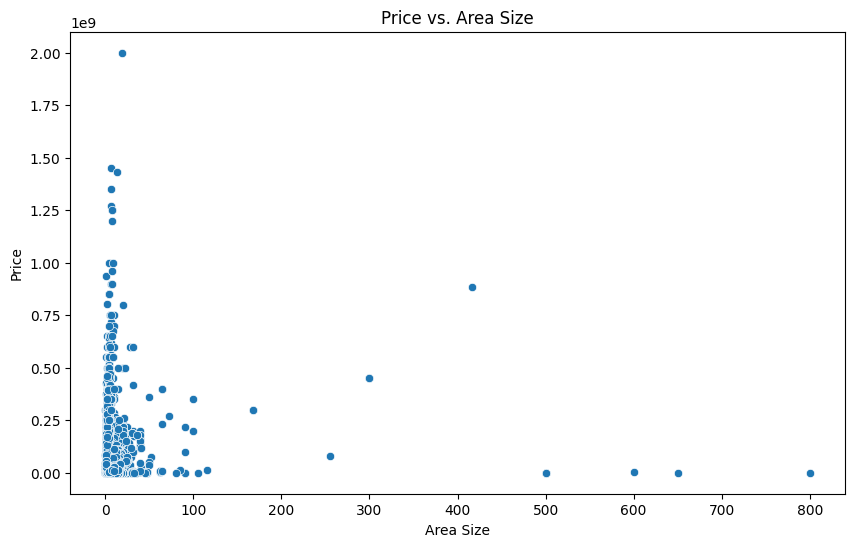

In [18]:
# Scatter plot to identify outliers in price vs. area size
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Area Size', y='price', data=df)
plt.title('Price vs. Area Size')
plt.xlabel('Area Size')
plt.ylabel('Price')
plt.show()

- ##### **Outliers in price**

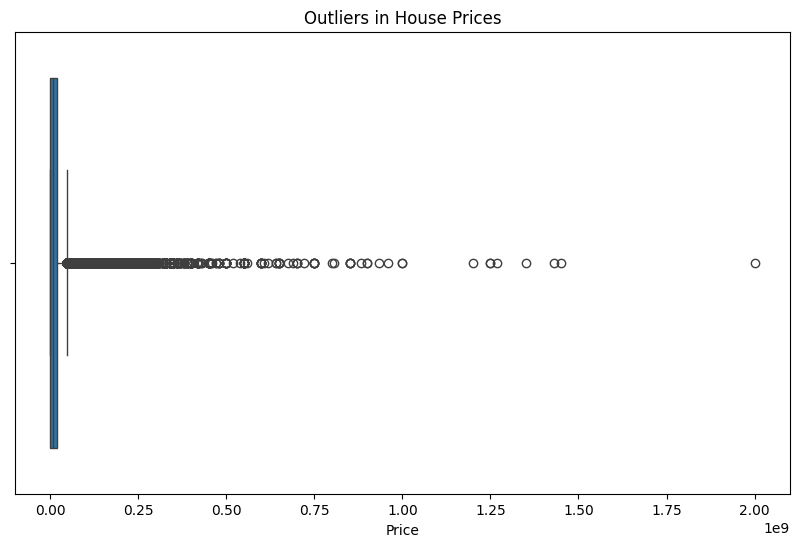

In [19]:
# Box plot to visualize outliers in price
plt.figure(figsize=(10, 6))
sns.boxplot(x='price', data=df)
plt.title('Outliers in House Prices')
plt.xlabel('Price')
plt.show()

- ##### **Outliers in Numerical Features**

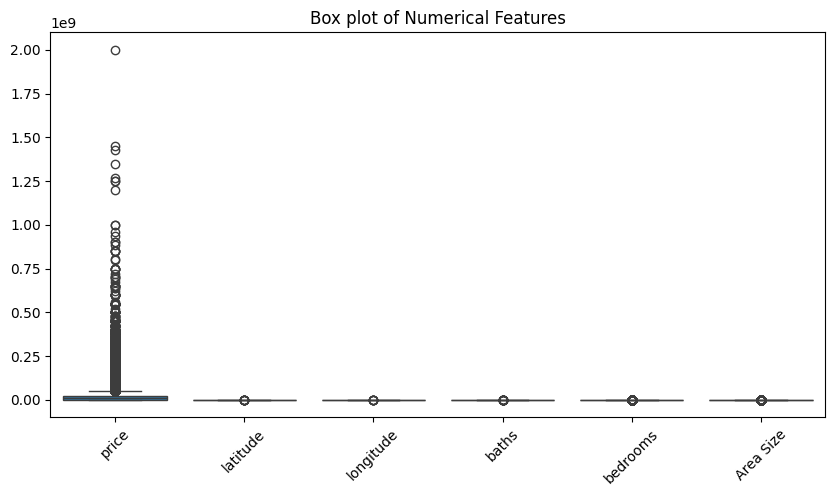

In [20]:
# Numerical columns for outlier detection
numerical_columns = ['price', 'latitude', 'longitude', 'baths', 'bedrooms', 'Area Size']

# Box plot visualization to identify outliers
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[numerical_columns])
plt.title('Box plot of Numerical Features')
plt.xticks(rotation=45)
plt.show()

  ##### **Statistical Methods for Outlier Detection and Handling**

- ##### **IQR Method***
  - The Interquartile Range (IQR) method is another popular method for outlier detection.

In [21]:
# Calculate IQR
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# Define Outlier Boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = (df[numerical_columns] < lower_bound) | (df[numerical_columns] > upper_bound)

# Count outliers for each numerical column
outliers_count = outliers.sum()
print("Number of Outliers:")
print(outliers_count)

Number of Outliers:
price        13547
latitude         0
longitude        0
baths            0
bedrooms         0
Area Size        0
dtype: int64


- ##### **Handling Outliers**

In [22]:
# Winsorize numerical columns
df['price'] = winsorize(df['price'], limits=[0.01, 0.01])
df['latitude'] = winsorize(df['latitude'], limits=[0.05, 0.05])
df['longitude'] = winsorize(df['longitude'], limits=[0.05, 0.05])
df['baths'] = winsorize(df['baths'], limits=[0.05, 0.05])
df['bedrooms'] = winsorize(df['bedrooms'], limits=[0.05, 0.05])
df['Area Size'] = winsorize(df['Area Size'], limits=[0.05, 0.05])

In [23]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile) for 'price'
Q1_price = df['price'].quantile(0.25)
Q3_price = df['price'].quantile(0.75)
IQR_price = Q3_price - Q1_price

# Define the upper and lower bounds for outlier detection
lower_bound_price = Q1_price - 1.5 * IQR_price
upper_bound_price = Q3_price + 1.5 * IQR_price

# Calculate the mean of 'price' and convert it to integer (int)
mean_price = int(df['price'].mean())

# Replace outliers with the mean
df.loc[df['price'] > upper_bound_price, 'price'] = mean_price
df.loc[df['price'] < lower_bound_price, 'price'] = mean_price

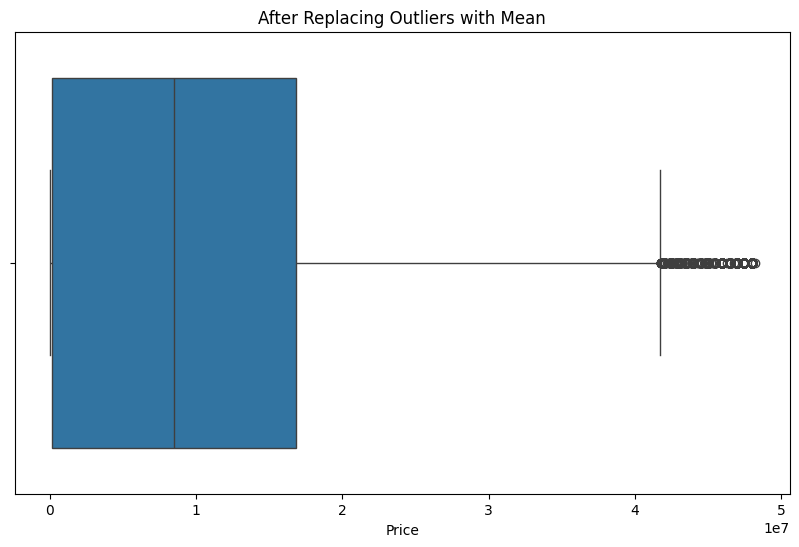

In [24]:
# Box plot to visualize outliers in price after outliers handling
plt.figure(figsize=(10, 6))
sns.boxplot(x='price', data=df)
plt.title('After Replacing Outliers with Mean')
plt.xlabel('Price')
plt.show()

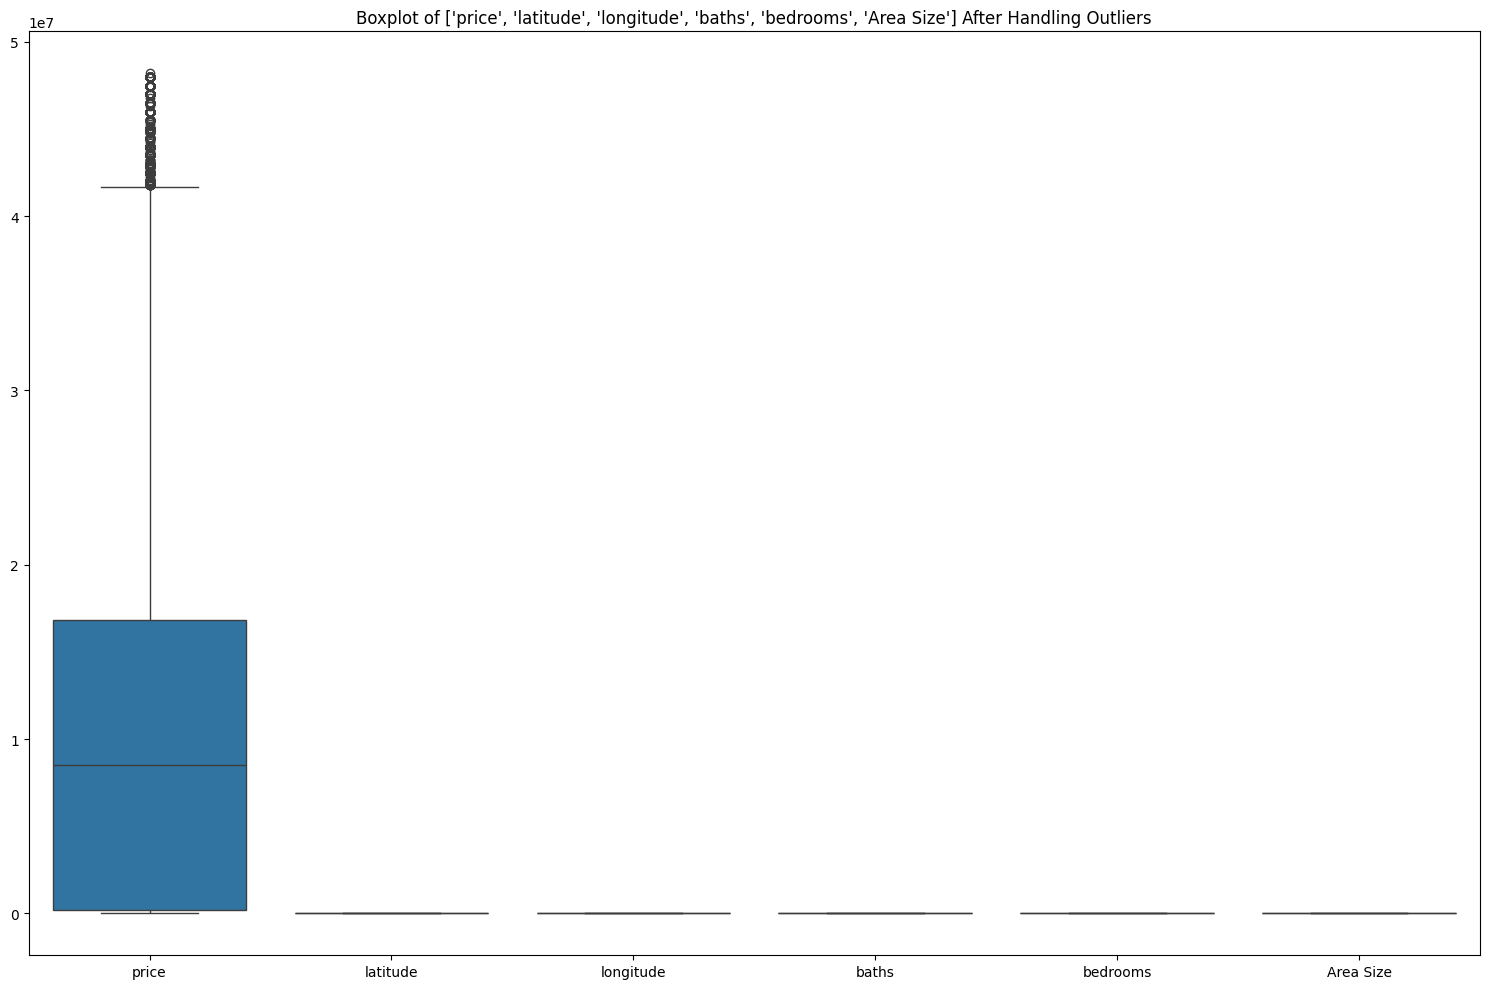

In [25]:
# Visualize numerical columns after handling outliers
plt.figure(figsize=(15, 10))
sns.boxplot(df[numerical_columns])
plt.title(f'Boxplot of {numerical_columns} After Handling Outliers')
plt.tight_layout()
plt.show()

- ##### **Outliers After Handling**

In [26]:
# Create a mask for outliers using NumPy operations
outliers_post = (df[numerical_columns] < lower_bound_price) | (df[numerical_columns] > upper_bound_price)

# Count outliers for each numerical column
outliers_count_post = outliers_post.sum()

# Print the number of outliers after handling
print("Number of Outliers After Handling:")
print(outliers_count_post)

Number of Outliers After Handling:
price        0
latitude     0
longitude    0
baths        0
bedrooms     0
Area Size    0
dtype: int64


#### **1.2. Data Exploration**

##### **a. Analyze the Distribution of House Prices**

 - ##### **Histogram and KDE Plot for Price Distribution**

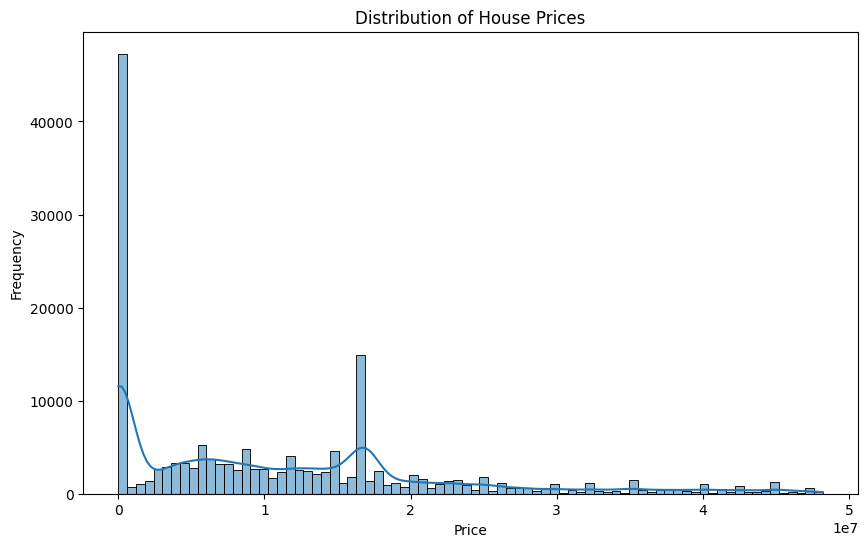

In [27]:
# Histogram and KDE Plot for Price Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

- ##### **Histograms & Box Plot for Numerical Features**

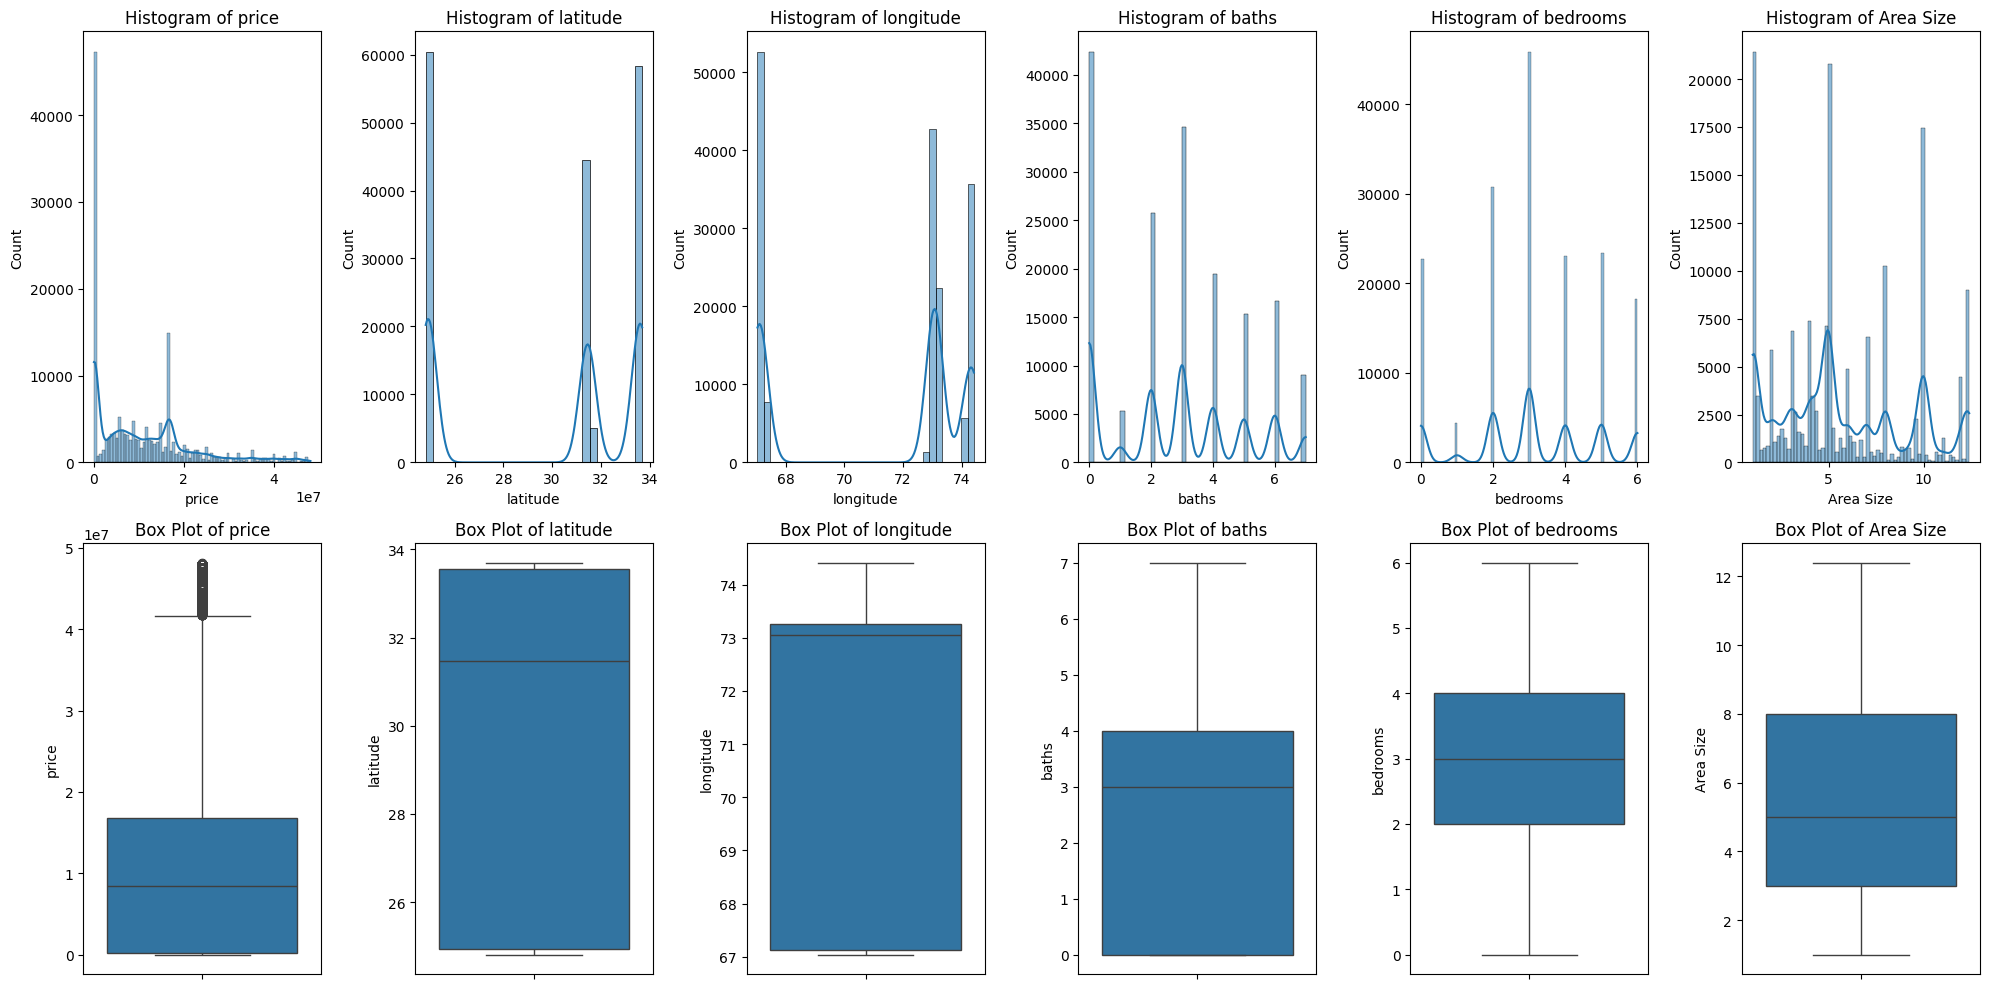

In [28]:
# Histograms and Box Plots for Numerical Features
numerical_columns = ['price', 'latitude', 'longitude', 'baths', 'bedrooms', 'Area Size']

plt.figure(figsize=(20, 10))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(2, len(numerical_columns), i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')
    
    plt.subplot(2, len(numerical_columns), len(numerical_columns) + i)
    sns.boxplot(df[col])
    plt.title(f'Box Plot of {col}')
plt.tight_layout()
plt.show()

- ##### **Scatter Plots to Identify Relationships Between Features and Price**

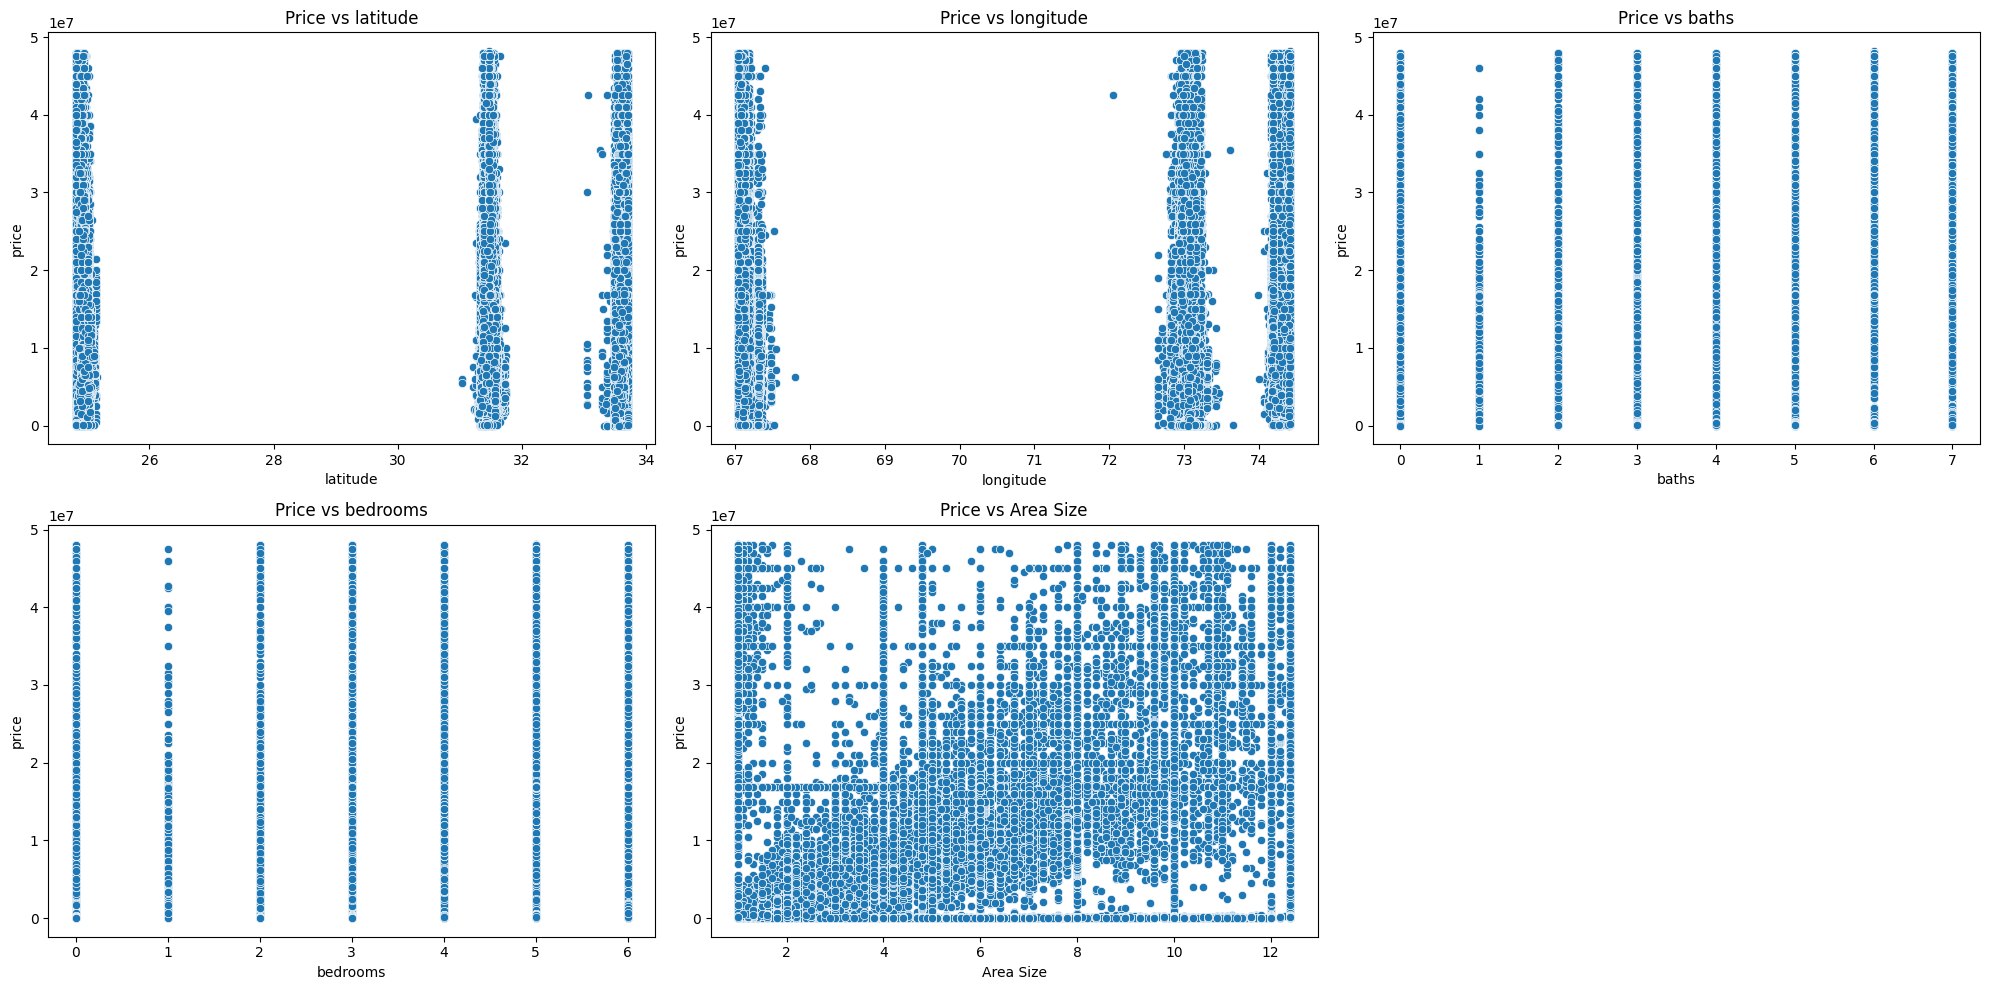

In [29]:
# Scatter Plots for Numerical Features vs. Price
plt.figure(figsize=(20, 10))
for i, col in enumerate(numerical_columns[1:], 1):  # Exclude 'price' from the loop
    plt.subplot(2, 3, i)
    sns.scatterplot(x=df[col], y=df['price'])
    plt.title(f'Price vs {col}')
plt.tight_layout()
plt.show()

- ##### **Bar Plots for Categorical Features vs. Price**

In [30]:
# Remove leading/trailing whitespace and standardize case
df['agency'] = df['agency'].str.strip().str.title()

# Handle missing values (optional)
df['agency'].fillna('Unknown', inplace=True)

0                            Unknown
1                            Unknown
2                            Unknown
3                            Unknown
4                      Easy Property
                     ...            
168441         Al Shahab Enterprises
168442         Al Shahab Enterprises
168443         Al Shahab Enterprises
168444         Al Shahab Enterprises
168445    Zpn Real Estate & Builders
Name: agency, Length: 168443, dtype: str

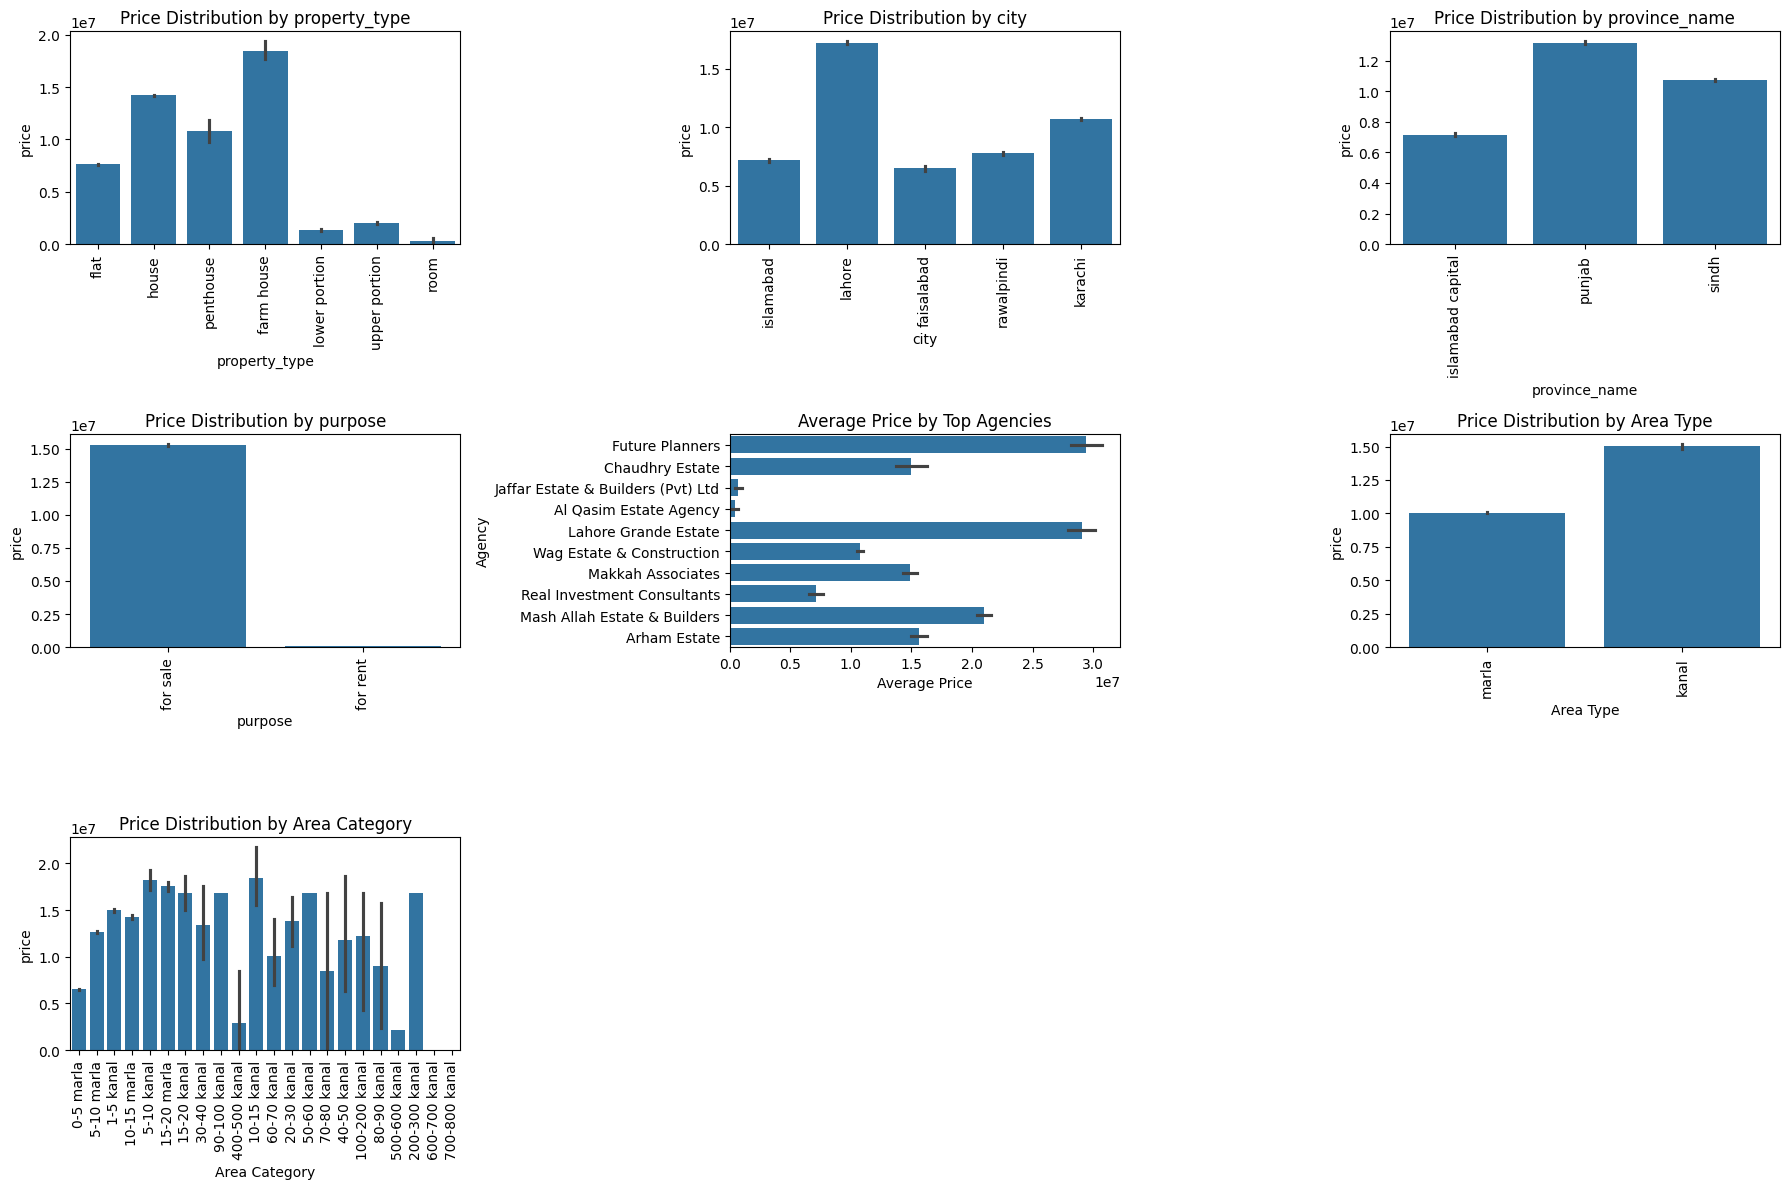

In [31]:
# Define categorical columns
categorical_columns = ['property_type', 'city', 'province_name', 'purpose', 'agency', 'Area Type', 'Area Category']

# Create bar plots for categorical features vs. price
plt.figure(figsize=(18, 12))  # Adjust figure size to accommodate all subplots

for i, col in enumerate(categorical_columns, 1):
    plt.subplot(3, 3, i)  # Use a 3x3 grid
    if col == 'agency':  # Special handling for 'agency'
        # Aggregate data for the top agencies
        top_agencies = df['agency'].value_counts().head(10).index
        filtered_df = df[df['agency'].isin(top_agencies)]
        sns.barplot(x='price', y='agency', data=filtered_df, estimator='mean')
        plt.title('Average Price by Top Agencies')
        plt.xlabel('Average Price')
        plt.ylabel('Agency')
    else:
        # For other categorical columns
        sns.barplot(x=df[col], y=df['price'], estimator='mean')  # Plot price distribution by categorical feature
        plt.xticks(rotation=90)  # Rotate x-axis labels for readability
        plt.title(f'Price Distribution by {col}')

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()


- ##### **Correlation Analysis**

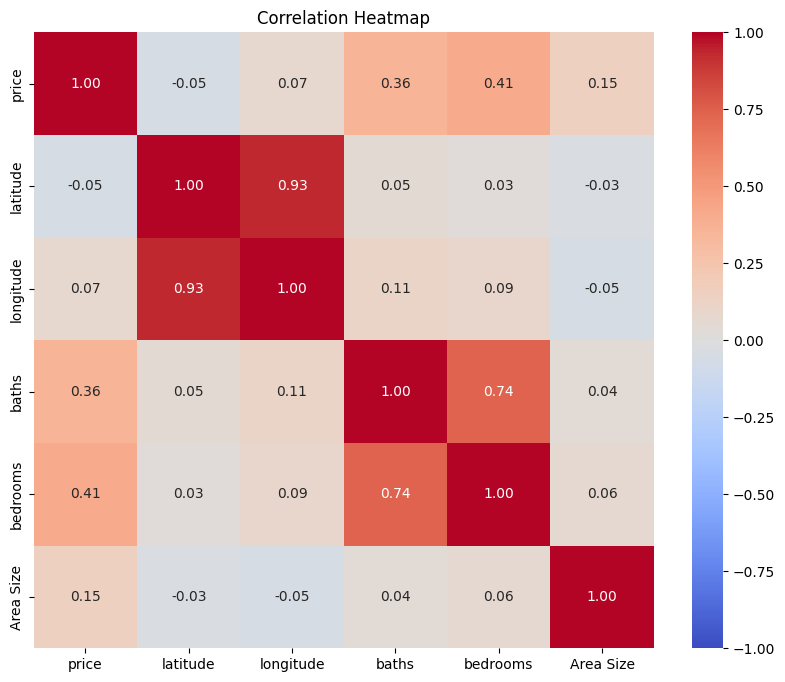

In [32]:
# Calculate correlation matrix
corr_matrix = df[numerical_columns].corr()

# Create a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

- ##### **Visualization of Geographical Data**

In [ ]:
# Calculate the mean latitude and longitude
mean_lat = df['latitude'].mean()
mean_lon = df['longitude'].mean()

# Create a map centered at the mean latitude and longitude
m = folium.Map(location=[mean_lat, mean_lon], zoom_start=6)

# Add a marker cluster to the map
marker_cluster = MarkerCluster().add_to(m)

# Add markers to the cluster
for _, row in df.iterrows():
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=f"Price: {row['price']}, Beds: {row['bedrooms']}, Baths: {row['baths']}"
    ).add_to(marker_cluster)

# Save the map to an HTML file
map_filename = 'house_price_map.html'
m.save(map_filename)

### **Feature Engineering**

##### **Create New Features**  

- ##### **Age of the House**

In [ ]:
from datetime import datetime

# Extract the year from 'date_added' and calculate the age
current_year = datetime.now().year
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['house_age'] = current_year - df['date_added'].dt.year // 365

# Handle any possible errors due to 'date_added' conversion by filling NaN with median age
df['house_age'].fillna(df['house_age'].median(), inplace=True)

- ##### **Convert area to Numeric**

In [ ]:
# Function to convert area measurements to square feet
def convert_area(area):
    if isinstance(area, str):
        area = area.replace(',', '')  # Remove commas from the string
        if 'Marla' in area:
            value = float(area.split()[0])
            return value * 272.25
        elif 'Kanal' in area:
            value = float(area.split()[0])
            return value * 20 * 272.25
        elif 'Square Feet' in area:
            value = float(area.split()[0])
            return value
    return area  

# Apply the conversion function to the 'area' column
df['area'] = df['area'].apply(convert_area)

In [ ]:
# Convert non-string values to strings
df['area'] = df['area'].astype(str)

# Remove non-numeric characters and convert 'area' to float
df['area'] = df['area'].str.replace(' Marla', '', regex=False).str.replace(',', '').astype(float)

# Verify the conversion
print(df[['area']].head())

- ##### **Calculate Price per Square Foot**

In [ ]:
# Calculate price per square foot
df['price_per_sqft'] = df['price'] / df['area']

- ##### **Number of Bedrooms Per Floor**

In [ ]:
# Create a new feature: number of bedrooms per floor
df['bedrooms_per_floor'] = df['bedrooms'] / df['area']

# Handle any possible errors due to division by zero or NaN values
df['bedrooms_per_floor'].replace([np.inf, -np.inf], np.nan, inplace=True)
df['bedrooms_per_floor'].fillna(df['bedrooms_per_floor'].median(), inplace=True)

- ##### **Bathrooms Per Bedroom**

In [ ]:
# Create a new feature: number of bathrooms per bedroom
df['baths_per_bedroom'] = df['baths'] / df['bedrooms']

# Handle any possible errors due to division by zero or NaN values
df['baths_per_bedroom'].replace([np.inf, -np.inf], np.nan, inplace=True)
df['baths_per_bedroom'].fillna(df['baths_per_bedroom'].median(), inplace=True)

- ##### **Displaying New Features**

In [ ]:
# Check if the new features are created
print(df.columns)

In [ ]:
# Display new features
print(df[['house_age', 'bedrooms_per_floor', 'baths_per_bedroom']].head())

- ##### **Encode Categorical Features**

- ##### **One-Hot Encoding**
    - Convert categorical variables into a format suitable for machine learning models using one-hot encoding.


In [ ]:
# List of categorical columns to encode
categorical_columns = [
    'property_type', 'location', 'city', 
    'province_name', 'purpose', 'agency', 
    'agent', 'Area Type', 'Area Category'
]

# Perform one-hot encoding on the categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

In [ ]:
# Display the first few rows of the encoded dataset
(df_encoded.head())

In [ ]:
# Save the dataset with new features
df.to_csv('new_features_dataset.csv', index=False)

##### **Outlier Analysis**

- ##### **Calculate Z-scores for 'price'**

In [ ]:
# Calculate Z-scores for 'price'
df['price_zscore'] = zscore(df['price'])

# Define a threshold for identifying outliers (e.g., z-score greater than 3 or less than -3)
outliers_high = df[df['price_zscore'] > 3]
outliers_low = df[df['price_zscore'] < -3]

# Display the number of outliers
print("Number of High Price Outliers:", len(outliers_high))
print("Number of Low Price Outliers:", len(outliers_low))

- ##### **Investigate Outliers**
    - ##### **Print Information About High Price Outliers***

In [ ]:
print("High Price Outliers:")
print(outliers_high[['property_id', 'price', 'location', 'area', 'bedrooms', 'baths', 'house_age']])

In [ ]:
# Set up the matplotlib figure
plt.figure(figsize=(16, 10))

# Plotting all visualizations in a single figure
plot_titles = ['Distribution of House Prices', 'Boxplot of Area', 'Boxplot of Bedrooms', 'Boxplot of Baths']
plot_data = [
    (df['price'], outliers_high['price'], 'Price', 'blue', 'red', 'Frequency'),
    (df['area'], outliers_high['area'], 'Area', 'blue', 'red', 'Area'),
    (df['bedrooms'], outliers_high['bedrooms'], 'Bedrooms', 'blue', 'red', 'Bedrooms'),
    (df['baths'], outliers_high['baths'], 'Baths', 'blue', 'red', 'Baths')
]

# Create subplots
for i, (data_all, data_outliers, feature_name, color_all, color_outliers, y_label) in enumerate(plot_data):
    plt.subplot(2, 2, i+1)
    if feature_name == 'Price':
        sns.histplot(data_all, kde=True, bins=50, color=color_all, label='All Properties')
        plt.scatter(data_outliers, [0] * len(data_outliers), color=color_outliers, label='High Price Outliers')
    else:
        sns.boxplot(data=data_all, color=color_all, width=0.5, label='All Properties')
        sns.boxplot(data=data_outliers, color=color_outliers, width=0.5, label='High Price Outliers')
    
    plt.title(f'{plot_titles[i]}')
    plt.xlabel(feature_name)
    plt.ylabel(y_label)
    plt.legend()

plt.tight_layout()
plt.show()

- ##### **Compare Summary Statistics**

In [ ]:
# Summary statistics for key features
summary_stats_all = df[['area', 'bedrooms', 'baths', 'house_age']].describe()
summary_stats_outliers = outliers_high[['area', 'bedrooms', 'baths', 'house_age']].describe()

print("Summary Statistics for All Properties:")
print(summary_stats_all)

print("\nSummary Statistics for High Price Outliers:")
print(summary_stats_outliers)

- ##### **Analyze Feature Contributions**

In [ ]:
# Correlation matrix for outliers
corr_outliers_high = outliers_high[['price', 'house_age', 'bedrooms', 'area', 'baths', 'price_per_sqft']].corr()

print("Correlation Matrix for High Price Outliers:")
print(corr_outliers_high)

- ##### **Investigate Specific Cases**

In [ ]:
# Manual inspection of extreme outliers
extreme_outliers_high = outliers_high.sort_values(by='price', ascending=False).head(10)
print("Extreme High Price Outliers:")
print(extreme_outliers_high[['price', 'house_age', 'bedrooms', 'area', 'baths', 'price_per_sqft']])

#### **Predictive Modeling**

In [ ]:
# Define features and target
features = ['area', 'bedrooms', 'baths', 'house_age', 'latitude', 'longitude']
target = 'price'

X = df[features]
y = df[target]

# Drop non-numeric columns
# df = df.drop(columns=['page_url'])

- ##### **Spliting the Data**

In [ ]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

##### **Linear Regression**

In [ ]:
# Train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

In [ ]:
# Make predictions
y_pred_lr = lr_model.predict(X_test)

# Evaluate the model
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance:")
print("Mean Absolute Error:", mae_lr)
print("Mean Squared Error:", mse_lr)
print("R-squared:", r2_lr)

##### **Random forest** 

In [ ]:
# Train the Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

In [ ]:
# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance:")
print("Mean Absolute Error:", mae_rf)
print("Mean Squared Error:", mse_rf)
print("R-squared:", r2_rf)

##### **Gradient Boosting**

In [ ]:
# Train the Gradient Boosting model
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

In [ ]:
# Make predictions
y_pred_gb = gb_model.predict(X_test)

# Evaluate the model
mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Performance:")
print("Mean Absolute Error:", mae_gb)
print("Mean Squared Error:", mse_gb)
print("R-squared:", r2_gb)

- ##### **Comparison of Actual vs Predicted House Prices**

In [ ]:
# Function to create scatter plot for a given model
def plot_predicted_vs_actual(ax, y_test, y_pred, model_name):
    ax.scatter(y_test, y_pred, alpha=0.5, label='Predicted vs Actual', zorder=3)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=3, label='Perfect Prediction', zorder=2)
    ax.set_xlabel('Actual Prices')
    ax.set_ylabel('Predicted Prices')
    ax.set_title(f'Actual vs Predicted House Prices ({model_name})')
    ax.legend()
    ax.grid(True, zorder=1)

# Set up the figure with subplots
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Plot for Linear Regression
plot_predicted_vs_actual(axs[0, 0], y_test, y_pred_lr, 'Linear Regression')

# Plot for Random Forest
plot_predicted_vs_actual(axs[0, 1], y_test, y_pred_rf, 'Random Forest')

# Plot for Gradient Boosting
plot_predicted_vs_actual(axs[1, 0], y_test, y_pred_gb, 'Gradient Boosting')

# Hide the empty subplot in the bottom right corner
axs[1, 1].axis('off')

# Add a main title for the whole figure
fig.suptitle('Comparison of Actual vs Predicted House Prices Using Different Models', fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the main title
plt.show()

- #### **Future Prediction**

In [ ]:
# Define the function to predict prices
def predict_prices(hypothetical_data, lr_model, rf_model, gb_model):
    # Create a DataFrame with hypothetical scenarios
    df_hypothetical = pd.DataFrame(hypothetical_data)
    
    # Use trained models to predict prices for hypothetical scenarios
    predicted_prices_lr = lr_model.predict(df_hypothetical)
    predicted_prices_rf = rf_model.predict(df_hypothetical)
    predicted_prices_gb = gb_model.predict(df_hypothetical)
    
    return predicted_prices_lr, predicted_prices_rf, predicted_prices_gb

In [ ]:
# Define the hypothetical scenarios (adjust as per your data structure)
hypothetical_data = {
    'area': [3000, 1800, 2200],  # in square feet
    'bedrooms': [5, 3, 4],
    'baths': [4, 2, 3],
    'house_age': [12, 7, 9],
    'latitude': [32.7767, 34.0522, 35.6895],
    'longitude': [96.7970, 118.2437, 139.6917]
}

# Call the function with the hypothetical data and trained models
predicted_prices_lr, predicted_prices_rf, predicted_prices_gb = predict_prices(hypothetical_data, lr_model, rf_model, gb_model)

In [ ]:
# Print the predicted prices for each model
print("Predicted Prices for Hypothetical Scenarios (Linear Regression):")
print(predicted_prices_lr)

print("\nPredicted Prices for Hypothetical Scenarios (Random Forest):")
print(predicted_prices_rf)

print("\nPredicted Prices for Hypothetical Scenarios (Gradient Boosting):")
print(predicted_prices_gb)

In [ ]:
# Create a DataFrame with hypothetical scenarios
df_hypothetical = pd.DataFrame(hypothetical_data)

# Use trained models to predict prices for hypothetical scenarios
predicted_prices_lr = lr_model.predict(df_hypothetical)
predicted_prices_rf = rf_model.predict(df_hypothetical)
predicted_prices_gb = gb_model.predict(df_hypothetical)

# Combine predictions into a DataFrame for easier plotting
predictions = pd.DataFrame({
    'Scenario': ['Scenario 1', 'Scenario 2', 'Scenario 3'],
    'Linear Regression': predicted_prices_lr,
    'Random Forest': predicted_prices_rf,
    'Gradient Boosting': predicted_prices_gb
})

In [ ]:
# Set the plot size and bar width
plt.figure(figsize=(12, 8))
bar_width = 0.25

# Set the positions of the bars on the x-axis
r1 = np.arange(len(predictions['Scenario']))
r2 = [x + bar_width for x in r1]
r3 = [x + bar_width for x in r2]

# Create the bars for each model
plt.bar(r1, predictions['Linear Regression'], color='blue', width=bar_width, edgecolor='grey', label='Linear Regression')
plt.bar(r2, predictions['Random Forest'], color='green', width=bar_width, edgecolor='grey', label='Random Forest')
plt.bar(r3, predictions['Gradient Boosting'], color='red', width=bar_width, edgecolor='grey', label='Gradient Boosting')

# Add labels and title
plt.xlabel('Scenario', fontweight='bold')
plt.ylabel('Predicted Price', fontweight='bold')
plt.xticks([r + bar_width for r in range(len(predictions['Scenario']))], predictions['Scenario'])
plt.title('Predicted Prices for Hypothetical Scenarios')

# Add legend
plt.legend()

# Show the plot
plt.show()

---